# Add Nonlinear Trend

`add_nonlinear_trend` overlays a **curved** amplitude path instead of a straight ramp.
A unit-interval template $f(t)$, $t \in [0, 1]$, is energy-matched to the series and scaled by `trend_strength`, then blended with the same `normalize` protocol as `add_linear_trend`.

The template is built from a named family. `convex=True` (default) **accelerates** toward the endpoint (e.g. $t^2$); `convex=False` time-reverses it into a **decelerating** ramp. Splines skip that flag because their knots already set the curvature.

| Parameter | Default | Role |
| --- | --- | --- |
| `kind` | `"polynomial"` | `polynomial`, `exponential`, `logarithmic`, `sigmoid`, `power`, `spline` (or `None` to sample) |
| `trend_strength` | 1.0 | Multiplier on the energy-matched template |
| `direction` | `"upward"` | Sign of the net change |
| `convex` | True | Accelerating vs decelerating (ignored for `spline`) |
| `curvature` | 2.0 | Fallback shape intensity when a family-specific argument is omitted |
| `degree` | 2 | Polynomial exponent |
| `growth_rate` | None | Exponential rate $r$ or logarithmic $k$ |
| `power` | None | Power-law exponent |
| `steepness` / `midpoint` | None / 0.5 | Logistic slope and inflection in $[0, 1]$ |
| `n_knots` / `knot_values` | 5 / None | Spline control points; omit values to draw a seeded random walk |
| `normalize` | True | Restore original mean / std after adding the trend |


In [1]:
%matplotlib inline
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join("..", "..")))

from s2generator.utils import (
    load_univariate,
    generate_arma_samples,
    generate_nonstationary_sine,
)
from s2generator.augmentation import add_nonlinear_trend, add_linear_trend

L = 512
rng = np.random.RandomState(0)
np.random.seed(0)

synth = np.asarray(generate_arma_samples(L), dtype=float)
real = load_univariate("ETTh1")[:L].astype(float)
sine = np.asarray(generate_nonstationary_sine(L), dtype=float)


def overlay_pair(originals, variants, titles, ylabel="value"):
    n = len(titles)
    fig, axes = plt.subplots(
        n, 2, figsize=(11.5, 2.55 * n), sharex=False, squeeze=False
    )
    col_titles = ["synthetic (ARMA)", "real (ETTh1 OT)"]
    for col, (orig, var_list) in enumerate(zip(originals, variants)):
        for row, (label, series) in enumerate(var_list):
            ax = axes[row, col]
            ax.plot(orig, color="0.55", lw=1.15, label="original")
            ax.plot(series, color="C0", lw=1.15, alpha=0.9, label=label)
            if row == 0:
                ax.set_title(col_titles[col], fontweight="bold")
            ax.legend(fontsize=8, loc="upper right", frameon=False)
            ax.grid(True, alpha=0.3)
            axes[row, 0].set_ylabel(titles[row], fontsize=10)
    axes[-1, 0].set_xlabel("t")
    axes[-1, 1].set_xlabel("t")
    fig.tight_layout()
    return fig


def sweep_grid(series_list, names, makers, param_title):
    n_s, n_p = len(series_list), len(makers)
    fig, axes = plt.subplots(n_s, n_p, figsize=(3.6 * n_p, 2.5 * n_s), squeeze=False)
    for i, (series, name) in enumerate(zip(series_list, names)):
        for j, (label, fn) in enumerate(makers):
            ax = axes[i, j]
            ax.plot(series, color="0.55", lw=1.0, label="original")
            ax.plot(fn(series), color="C3", lw=1.05, alpha=0.9, label=label)
            if i == 0:
                ax.set_title(label, fontsize=10)
            if j == 0:
                ax.set_ylabel(name)
            ax.grid(True, alpha=0.3)
            if i == 0 and j == n_p - 1:
                ax.legend(fontsize=7, loc="upper right", frameon=False)
    fig.suptitle(param_title, y=1.02, fontweight="bold")
    fig.tight_layout()
    return fig

## Default quadratic trend on synthetic and real series

With the defaults (`kind="polynomial"`, `degree=2`, `convex=True`) the series picks up an accelerating tilt. `normalize=True` keeps the original mean and std, so the effect is a **bend** rather than a change in overall scale.


orig std / aug std  synth 0.82 0.82  real 4.813 4.813


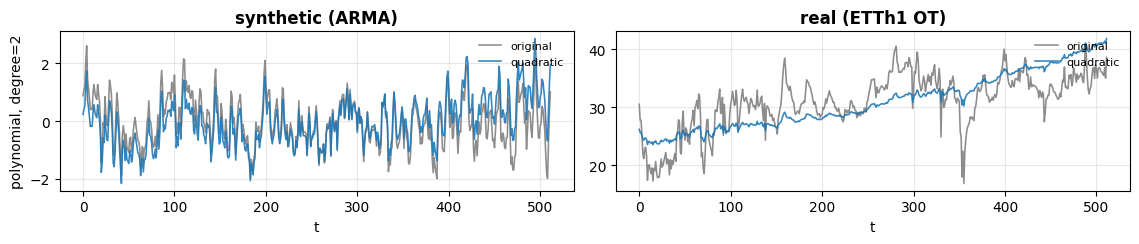

In [2]:
aug_synth = add_nonlinear_trend(synth, seed=0)
aug_real = add_nonlinear_trend(real, seed=0)
fig = overlay_pair(
    originals=[synth, real],
    variants=[[("quadratic", aug_synth)], [("quadratic", aug_real)]],
    titles=["polynomial, degree=2"],
)
print(
    "orig std / aug std  synth",
    round(float(synth.std()), 3),
    round(float(aug_synth.std()), 3),
    " real",
    round(float(real.std()), 3),
    round(float(aug_real.std()), 3),
)

## Compare trend families

Each column uses the same `trend_strength=1.2` and an upward direction. Linear is shown as a reference; the other families share that net energy but differ in **when** the rise happens.


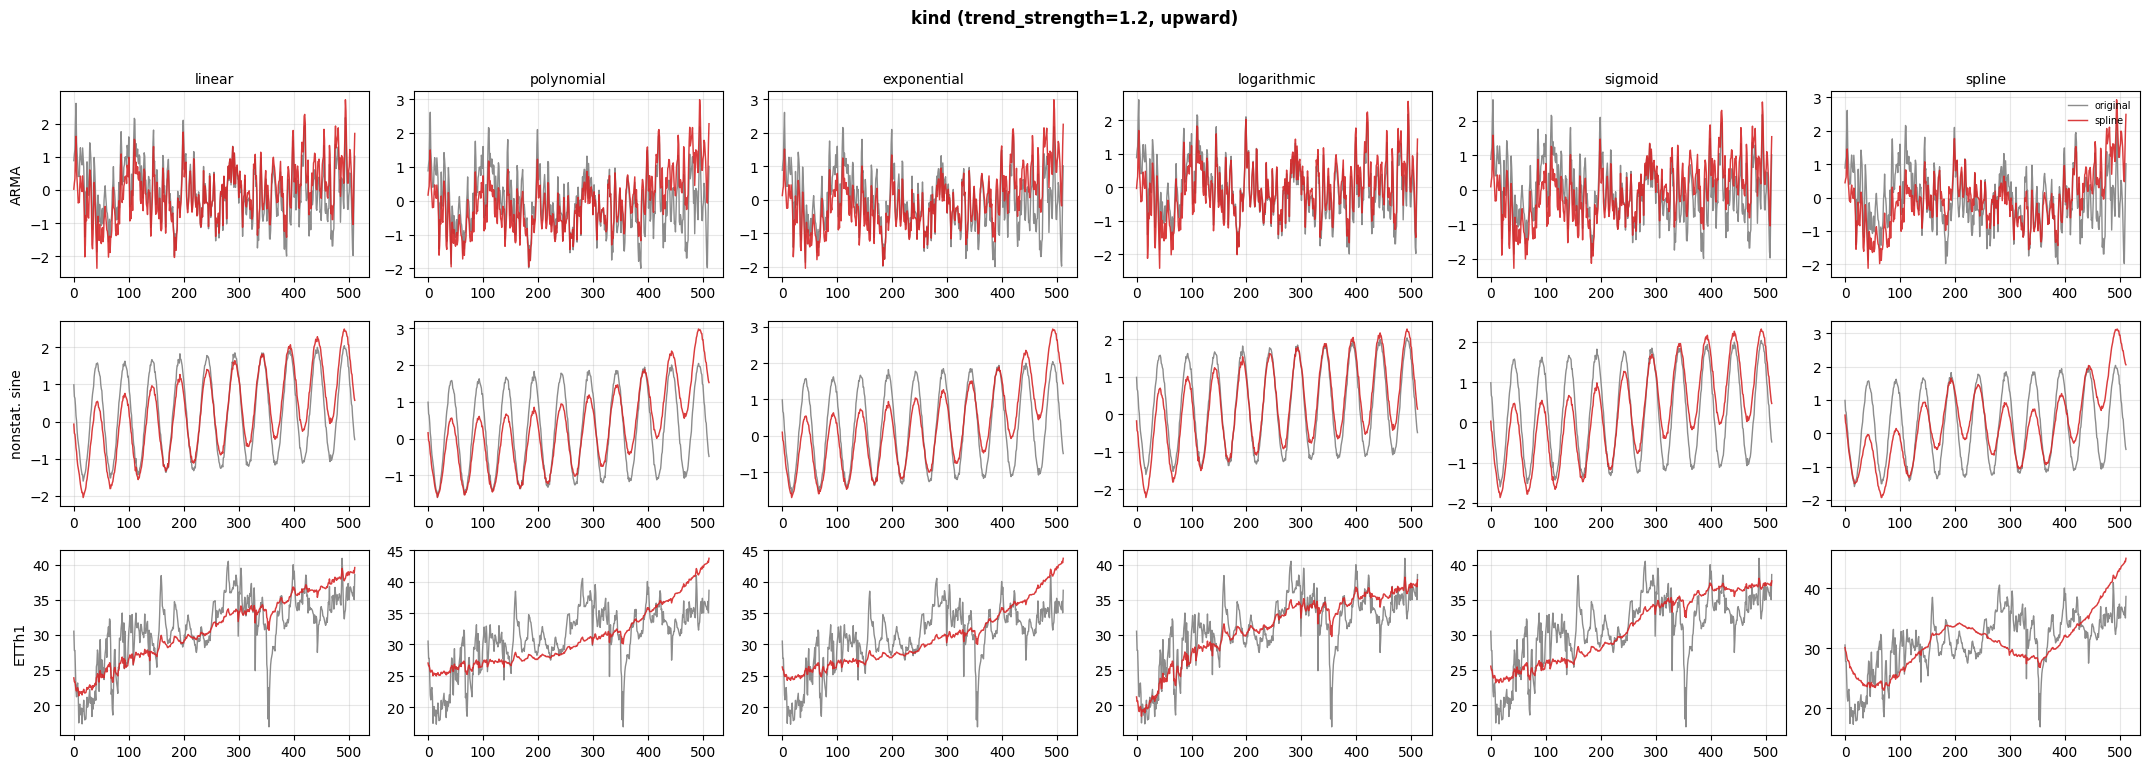

In [3]:
kinds = [
    ("linear", lambda x: add_linear_trend(x, trend_strength=1.2, direction="upward")),
    (
        "polynomial",
        lambda x: add_nonlinear_trend(
            x, kind="polynomial", degree=3, trend_strength=1.2
        ),
    ),
    (
        "exponential",
        lambda x: add_nonlinear_trend(
            x, kind="exponential", growth_rate=3.0, trend_strength=1.2
        ),
    ),
    (
        "logarithmic",
        lambda x: add_nonlinear_trend(
            x, kind="logarithmic", growth_rate=8.0, trend_strength=1.2
        ),
    ),
    (
        "sigmoid",
        lambda x: add_nonlinear_trend(
            x, kind="sigmoid", steepness=10.0, midpoint=0.5, trend_strength=1.2
        ),
    ),
    (
        "spline",
        lambda x: add_nonlinear_trend(
            x, kind="spline", n_knots=6, seed=4, trend_strength=1.2
        ),
    ),
]
fig = sweep_grid(
    [synth, sine, real],
    ["ARMA", "nonstat. sine", "ETTh1"],
    kinds,
    "kind (trend_strength=1.2, upward)",
)

## Convex vs concave and curvature

`convex=True` loads the change toward the **end** of the window; `convex=False` loads it toward the **start**. `curvature` / `power` / `growth_rate` control how sharp that bend is. A power-law with `power=1` is linear.


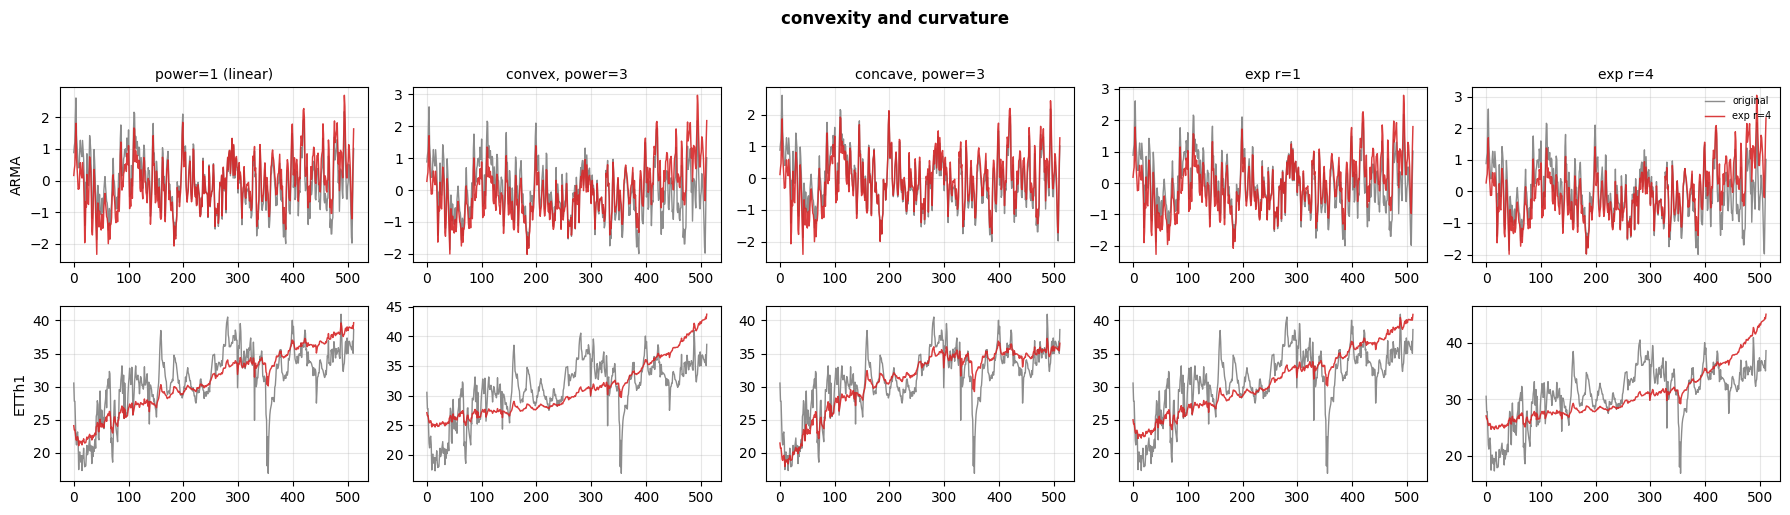

In [4]:
makers = [
    ("power=1 (linear)", lambda x: add_nonlinear_trend(x, kind="power", power=1.0)),
    (
        "convex, power=3",
        lambda x: add_nonlinear_trend(x, kind="power", power=3.0, convex=True),
    ),
    (
        "concave, power=3",
        lambda x: add_nonlinear_trend(x, kind="power", power=3.0, convex=False),
    ),
    ("exp r=1", lambda x: add_nonlinear_trend(x, kind="exponential", growth_rate=1.0)),
    ("exp r=4", lambda x: add_nonlinear_trend(x, kind="exponential", growth_rate=4.0)),
]
fig = sweep_grid(
    [synth, real],
    ["ARMA", "ETTh1"],
    makers,
    "convexity and curvature",
)

## Strength, direction, and normalisation

`trend_strength` scales the energy-matched template. `direction` flips the sign. With `normalize=False` the series is averaged with the trend, so the amplitude can drift; the default `normalize=True` restores the original mean and std.


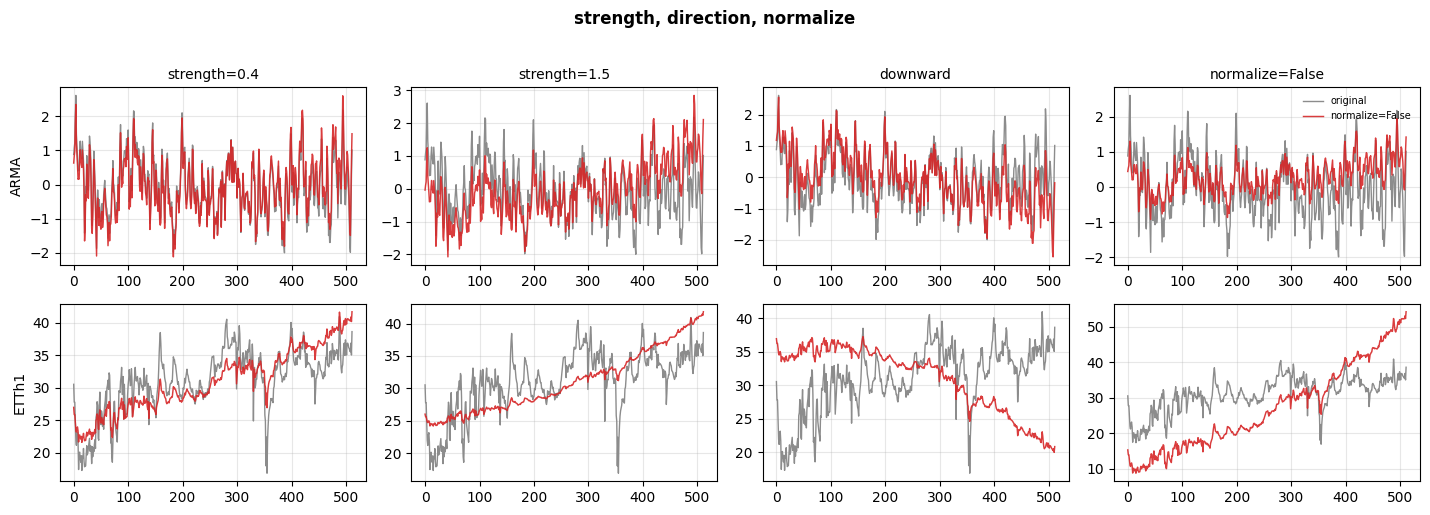

In [5]:
makers = [
    (
        "strength=0.4",
        lambda x: add_nonlinear_trend(
            x, kind="polynomial", degree=2, trend_strength=0.4
        ),
    ),
    (
        "strength=1.5",
        lambda x: add_nonlinear_trend(
            x, kind="polynomial", degree=2, trend_strength=1.5
        ),
    ),
    (
        "downward",
        lambda x: add_nonlinear_trend(
            x, kind="polynomial", degree=2, direction="downward"
        ),
    ),
    (
        "normalize=False",
        lambda x: add_nonlinear_trend(x, kind="polynomial", degree=2, normalize=False),
    ),
]
fig = sweep_grid(
    [synth, real],
    ["ARMA", "ETTh1"],
    makers,
    "strength, direction, normalize",
)

## Sigmoid: steepness and inflection

A logistic template stays almost flat, then transitions around `midpoint`. Larger `steepness` makes the jump sharper — useful for regime-shift style non-stationarity rather than a slow drift.


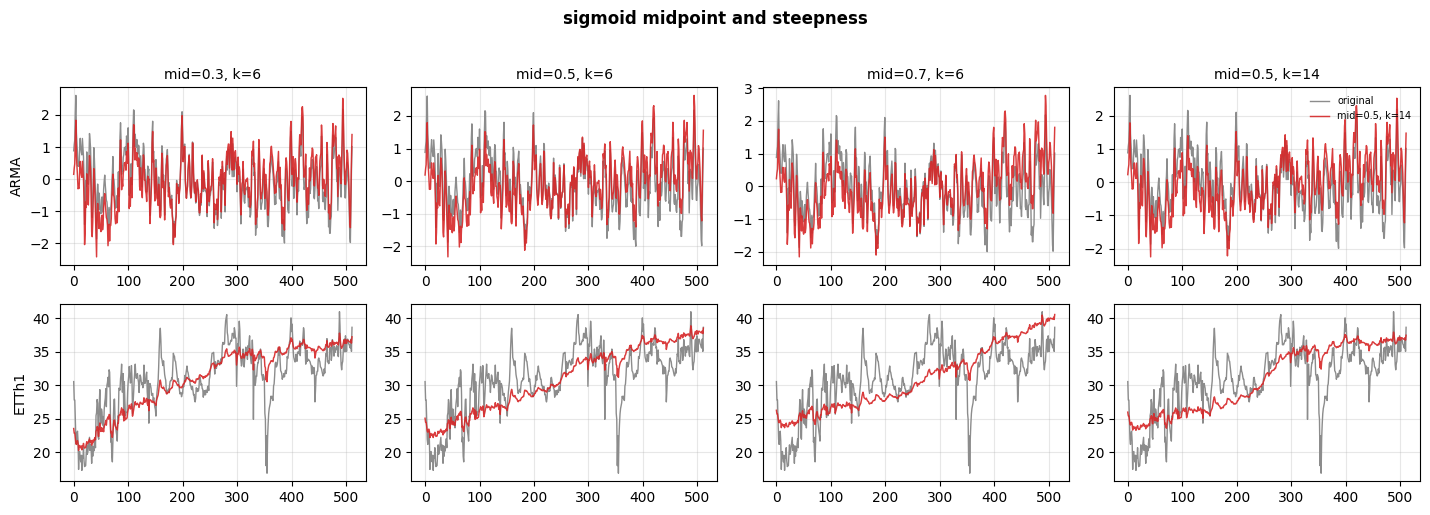

In [6]:
makers = [
    (
        "mid=0.3, k=6",
        lambda x: add_nonlinear_trend(x, kind="sigmoid", midpoint=0.3, steepness=6.0),
    ),
    (
        "mid=0.5, k=6",
        lambda x: add_nonlinear_trend(x, kind="sigmoid", midpoint=0.5, steepness=6.0),
    ),
    (
        "mid=0.7, k=6",
        lambda x: add_nonlinear_trend(x, kind="sigmoid", midpoint=0.7, steepness=6.0),
    ),
    (
        "mid=0.5, k=14",
        lambda x: add_nonlinear_trend(x, kind="sigmoid", midpoint=0.5, steepness=14.0),
    ),
]
fig = sweep_grid(
    [synth, real],
    ["ARMA", "ETTh1"],
    makers,
    "sigmoid midpoint and steepness",
)

## Spline control points

Pass `knot_values` for a deterministic cubic path (endpoints are rescaled to a unit ramp). Omit them to draw a seeded random walk through `n_knots` knots — two draws with the same `seed` match; a different seed does not.


same seed identical: True


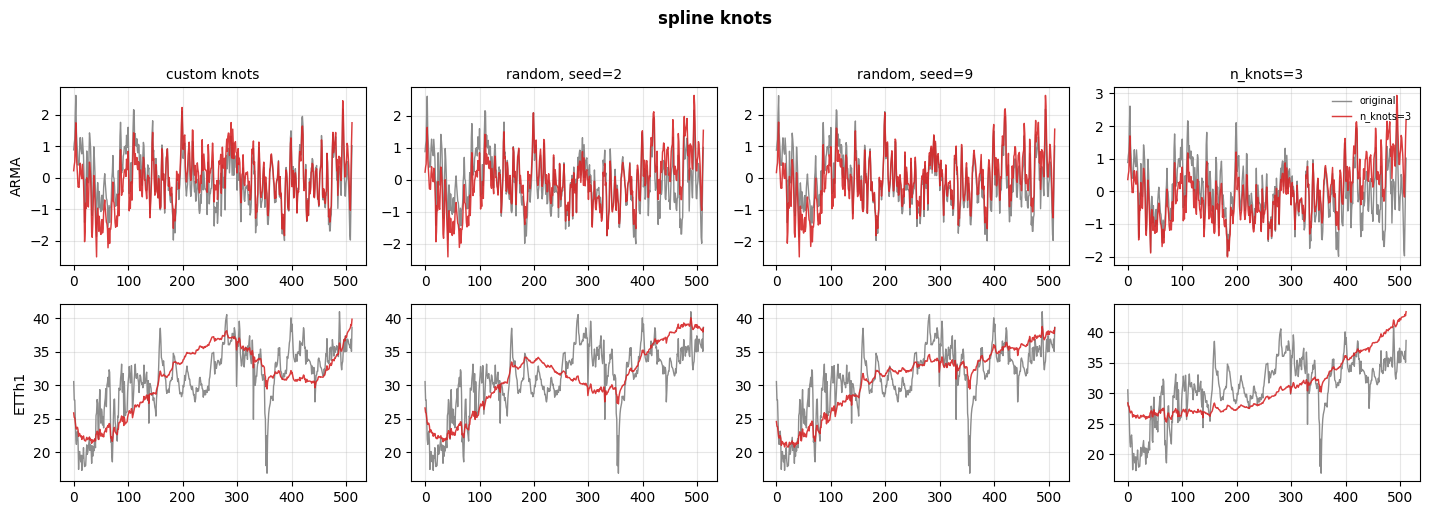

In [7]:
makers = [
    (
        "custom knots",
        lambda x: add_nonlinear_trend(
            x,
            kind="spline",
            n_knots=5,
            knot_values=(0.0, 0.15, 0.85, 0.4, 1.0),
        ),
    ),
    (
        "random, seed=2",
        lambda x: add_nonlinear_trend(x, kind="spline", n_knots=6, seed=2),
    ),
    (
        "random, seed=9",
        lambda x: add_nonlinear_trend(x, kind="spline", n_knots=6, seed=9),
    ),
    ("n_knots=3", lambda x: add_nonlinear_trend(x, kind="spline", n_knots=3, seed=2)),
]
fig = sweep_grid(
    [synth, real],
    ["ARMA", "ETTh1"],
    makers,
    "spline knots",
)

a = add_nonlinear_trend(synth, kind="spline", n_knots=6, seed=2)
b = add_nonlinear_trend(synth, kind="spline", n_knots=6, seed=2)
print("same seed identical:", np.allclose(a, b))